<a href="https://colab.research.google.com/github/tanjiro-01/real_estate_cf/blob/main/real_estate_cf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Readme

In [ ]:
"""
Real Estate Underwriting Score Prediction System
Thejaswi Bhat H
CodeFrontier Software

Objective
Build a Machine Learning model to predict an underwriting score (0–100) and categorize risk levels for real estate investment decisions.


1. Problem Description
2. Import Libraries
3. Load Dataset
4. Data Quality Checks
5. Exploratory Data Analysis (EDA)
6. Data Cleaning

Builder Score (25%)
Property Score (35%)
Market Score (20%)
Financial Score (20%)

"""

'\nReal Estate Underwriting Score Prediction System\nThejaswi Bhat H \nCodeFrontier Software \n\nObjective\nBuild a Machine Learning model to predict an underwriting score (0–100) and categorize risk levels for real estate investment decisions.\n\n1. Problem Description\n2. Import Libraries\n3. Load Dataset\n4. Data Quality Checks\n5. Exploratory Data Analysis (EDA)\n6. Data Cleaning\n'

# Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Load data

In [7]:
file_path = "/content/drive/MyDrive/CF/data/data.xlsx"
df = pd.read_excel(file_path)

print(df.shape)
df.head()


(500, 43)


,property_id,city,builder_name,builder_years_in_business,projects_completed,avg_delay_months,debt_to_equity_ratio,rera_violations,litigation_count,is_publicly_listed,...,payment_plan_type,builder_score,property_score,market_score,financial_score,underwriting_score,risk_category,expected_irr_pct,recommendation,confidence_level
0,VAD-2024-0001,Vadodara,Mahindra Lifespaces,18,40,4.4,0.50,0,0,1,...,CLP,92.5,67.5,54.0,40.0,70.5,Moderate Risk,3.2,INVEST,High
1,SUR-2024-0002,Surat,Local Builder 1,9,13,6.7,2.64,1,7,0,...,CLP,54.0,51.5,57.5,55.5,44.1,High Risk,2.9,AVOID,High
2,BAN-2024-0003,Bangalore,Piramal Realty,10,10,4.1,1.07,0,0,1,...,CLP,77.5,74.5,43.5,48.0,68.8,Moderate Risk,4.8,INVEST,Medium
3,IND-2024-0004,Indore,Jaypee Group,26,54,28.0,3.32,9,19,0,...,SUB,44.0,52.5,62.5,63.0,36.5,High Risk,14.7,AVOID,High
4,MUM-2024-0005,Mumbai,Prestige Group,30,93,1.3,1.30,0,0,1,...,CLP,86.5,57.5,71.0,76.0,74.2,Moderate Risk,15.6,INVEST,Medium


In [9]:
# null check
df.info()
df.isnull().sum().sort_values(ascending=False).head(20)
df.duplicated().sum()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   property_id                500 non-null    object 
 1   city                       500 non-null    object 
 2   builder_name               500 non-null    object 
 3   builder_years_in_business  500 non-null    int64  
 4   projects_completed         500 non-null    int64  
 5   avg_delay_months           500 non-null    float64
 6   debt_to_equity_ratio       500 non-null    float64
 7   rera_violations            500 non-null    int64  
 8   litigation_count           500 non-null    int64  
 9   is_publicly_listed         500 non-null    int64  
 10  net_worth_crores           500 non-null    int64  
 11  city_tier                  500 non-null    int64  
 12  distance_to_metro_km       500 non-null    float64
 13  distance_to_cbd_km         500 non-null    float64

np.int64(0)

# Data Checks

In [10]:
df.columns
df.dtypes

,0
property_id,object
city,object
builder_name,object
builder_years_in_business,int64
projects_completed,int64
avg_delay_months,float64
debt_to_equity_ratio,float64
rera_violations,int64
litigation_count,int64
is_publicly_listed,int64


In [11]:
#missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

missing_percent = (df.isnull().sum()/len(df))*100
missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": missing_percent
}).sort_values(by="missing_count", ascending=False)

missing_report.head(15)



,missing_count,missing_percent
property_id,0,0.0
city,0,0.0
builder_name,0,0.0
builder_years_in_business,0,0.0
projects_completed,0,0.0
avg_delay_months,0,0.0
debt_to_equity_ratio,0,0.0
rera_violations,0,0.0
litigation_count,0,0.0
is_publicly_listed,0,0.0


In [12]:
#duplicate check
df.duplicated().sum()


np.int64(0)

In [13]:
df["underwriting_score"].describe()


,underwriting_score
count,500.000000
mean,65.652200
std,9.914653
min,29.600000
25%,61.675000
50%,67.050000
75%,72.000000
max,86.800000


In [14]:
df["risk_category"].value_counts()


,count
risk_category,
Moderate Risk,303
Medium-High Risk,136
High Risk,41
Low Risk,15
Avoid,5


# Exploratory data analysis
explore dataset to understand distributions relationships
outliers patterns that affect performance.

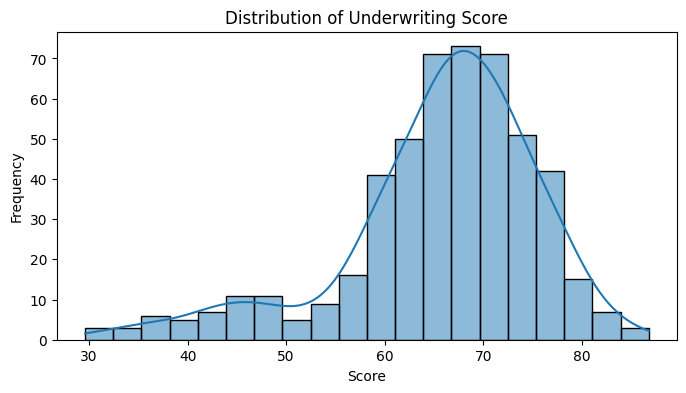

In [15]:
plt.figure(figsize=(8,4))
sns.histplot(df["underwriting_score"], bins=20, kde=True)
plt.title("Distribution of Underwriting Score")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()


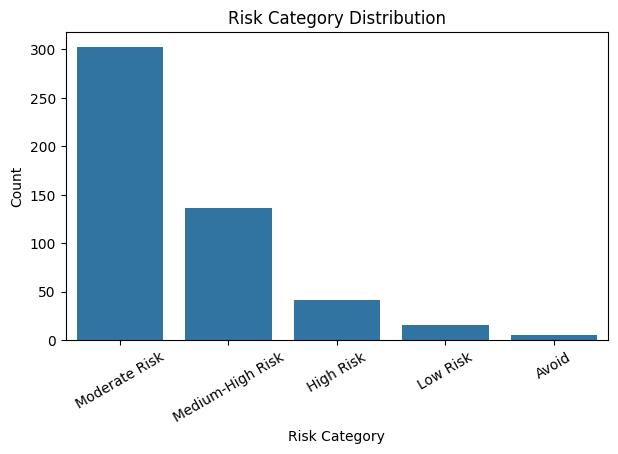

In [16]:
plt.figure(figsize=(7,4))
sns.countplot(
    data=df,
    x="risk_category",
    order=df["risk_category"].value_counts().index
)
plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()


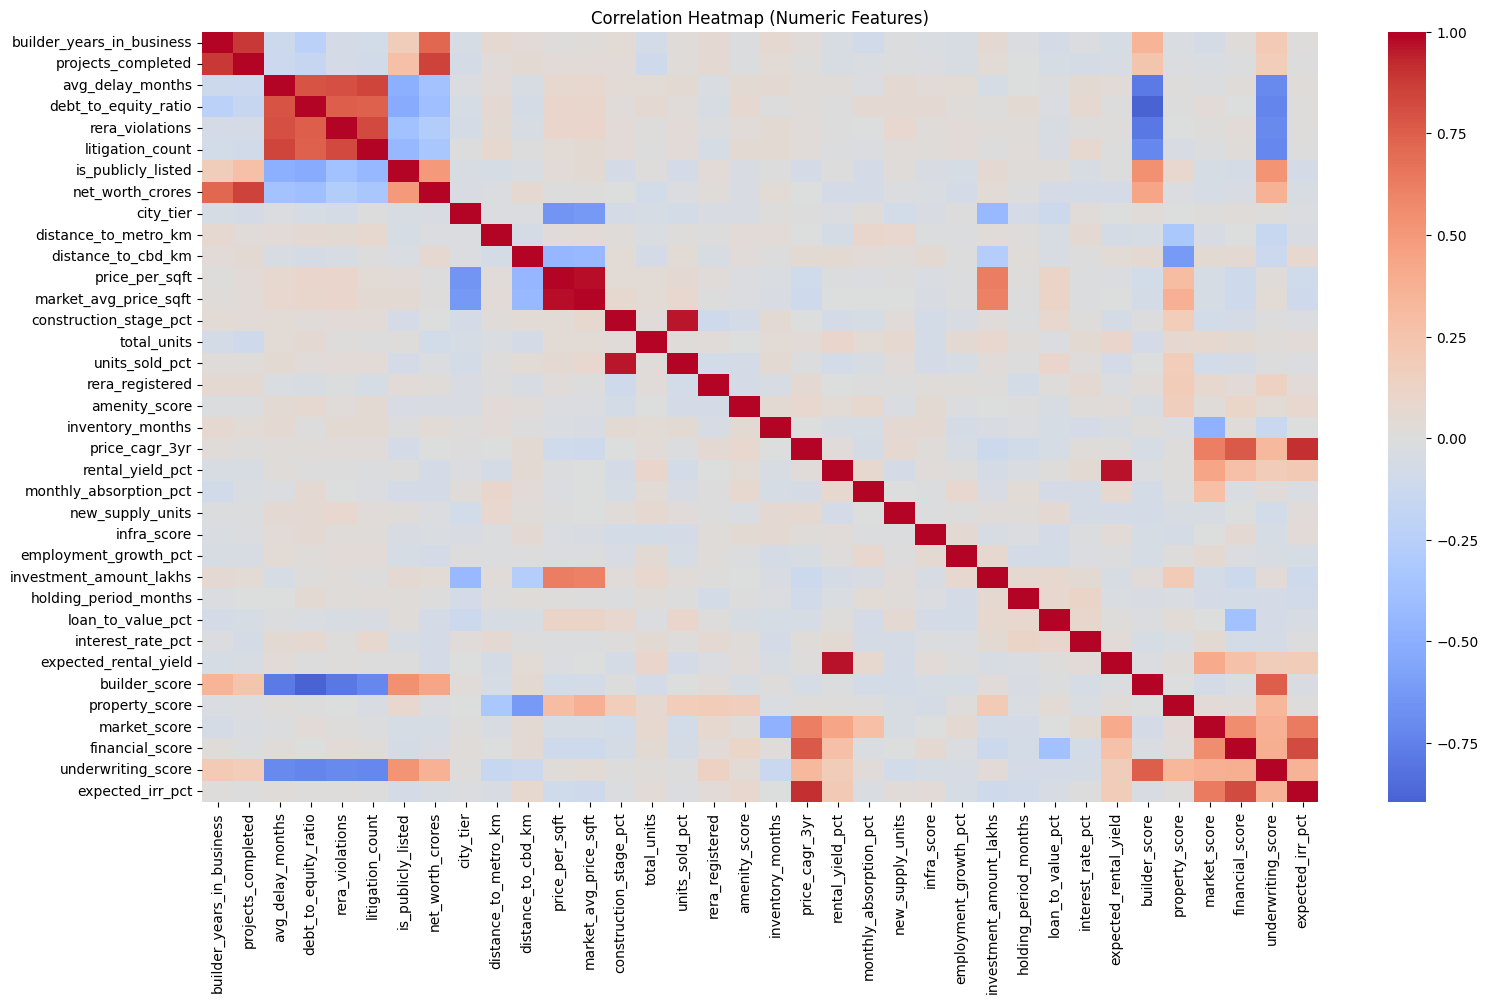

In [17]:
plt.figure(figsize=(18,10))

numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


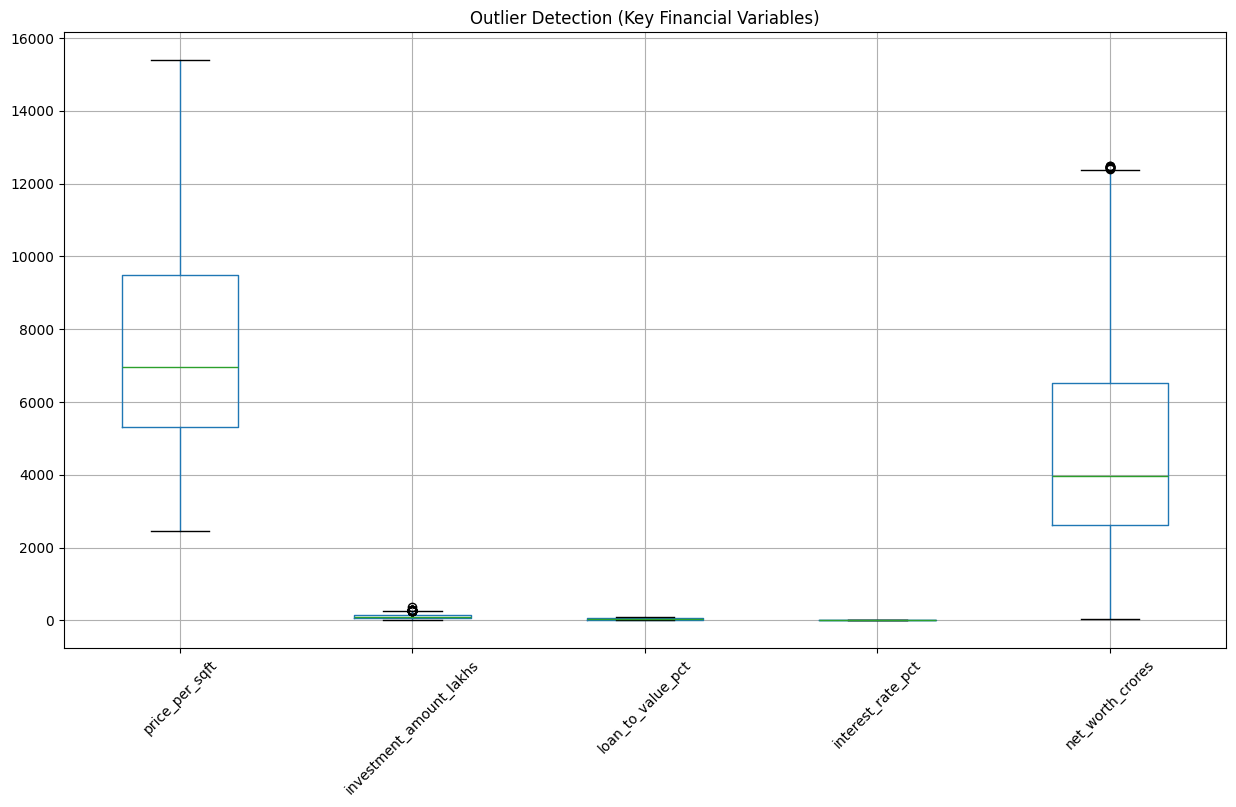

In [18]:
key_cols = [
    "price_per_sqft",
    "investment_amount_lakhs",
    "loan_to_value_pct",
    "interest_rate_pct",
    "net_worth_crores"
]

plt.figure(figsize=(15,8))
df[key_cols].boxplot()
plt.title("Outlier Detection (Key Financial Variables)")
plt.xticks(rotation=45)
plt.show()


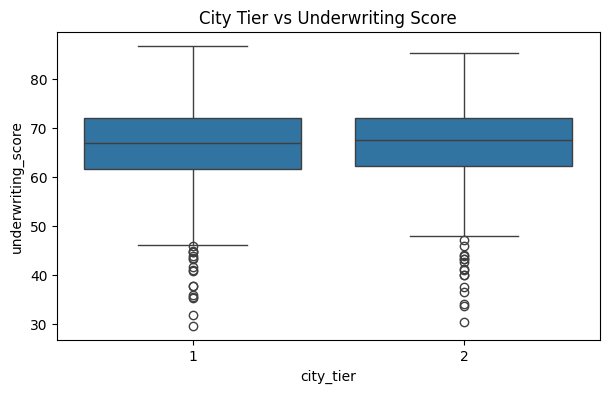

In [19]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="city_tier", y="underwriting_score")
plt.title("City Tier vs Underwriting Score")
plt.show()


insights:

1. The underwriting score distribution shows that most projects fall within the medium to high score range, indicating generally moderate risk profiles.

2. Risk category analysis reveals that the majority of properties belong to the Moderate and Medium-High risk segments.

3. Correlation analysis indicates that variables such as units_sold_pct, price_per_sqft, builder experience, and net_worth_crores have strong influence on the underwriting score.

4. Outlier analysis shows the presence of extreme values in financial variables such as investment_amount_lakhs and loan_to_value_pct, which require treatment.

5. Projects located in Tier-1 cities generally demonstrate higher underwriting scores compared to Tier-2 and Tier-3 cities.


# Data cleaning & preprocessing

In [26]:
before_stats = df.describe()
before_stats



In [29]:

df_raw = df.copy()

In [27]:
def remove_outliers_iqr(data, cols):
    cleaned = data.copy()

    for col in cols:
        Q1 = cleaned[col].quantile(0.25)
        Q3 = cleaned[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        cleaned = cleaned[
            (cleaned[col] >= lower) &
            (cleaned[col] <= upper)
        ]

    return cleaned


num_cols = df.select_dtypes(include=np.number).columns

df = remove_outliers_iqr(df, num_cols)

print("After outlier removal:", df.shape)


After outlier removal: (273, 45)


In [28]:
df["builder_experience_score"] = (
    df["builder_years_in_business"] * df["projects_completed"]
)

df["price_market_ratio"] = (
    df["price_per_sqft"] / df["market_avg_price_sqft"]
)


In [30]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [31]:
after_stats = df.describe()
after_stats


,builder_years_in_business,projects_completed,avg_delay_months,debt_to_equity_ratio,rera_violations,litigation_count,is_publicly_listed,net_worth_crores,city_tier,distance_to_metro_km,...,interest_rate_pct,expected_rental_yield,builder_score,property_score,market_score,financial_score,underwriting_score,expected_irr_pct,builder_experience_score,price_market_ratio
count,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,...,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000,273.000000
mean,22.699634,57.549451,4.287912,1.037399,0.875458,1.989011,0.728938,4524.644689,1.402930,7.557875,...,9.601832,3.510623,81.010623,59.448718,60.757509,64.805861,69.234799,9.574725,1554.739927,1.006244
std,8.992106,31.707045,2.345937,0.365424,1.067166,1.579937,0.445325,1888.974674,0.491388,4.268380,...,1.137026,1.175421,6.747254,8.000754,12.467633,12.906438,5.923756,6.166422,1212.054852,0.090784
min,3.000000,3.000000,0.000000,0.240000,0.000000,0.000000,0.000000,1300.000000,1.000000,0.400000,...,7.500000,1.200000,64.000000,42.500000,29.500000,38.500000,55.000000,-3.300000,9.000000,0.869594
25%,17.000000,32.000000,2.500000,0.760000,0.000000,1.000000,0.000000,3099.000000,1.000000,3.800000,...,8.600000,2.600000,76.500000,54.500000,52.800000,55.500000,65.300000,4.400000,570.000000,0.923602
50%,23.000000,56.000000,4.100000,1.020000,1.000000,2.000000,1.000000,4019.000000,1.000000,7.600000,...,9.500000,3.500000,81.500000,59.500000,60.500000,64.500000,69.300000,9.900000,1416.000000,0.988382
75%,30.000000,80.000000,6.000000,1.280000,2.000000,3.000000,1.000000,5700.000000,2.000000,11.300000,...,10.600000,4.500000,86.500000,64.500000,69.500000,74.500000,73.300000,14.500000,2072.000000,1.088485
max,37.000000,124.000000,11.100000,1.970000,5.000000,6.000000,1.000000,8952.000000,2.000000,15.000000,...,11.500000,5.700000,97.000000,79.500000,94.000000,95.000000,85.300000,21.800000,4440.000000,1.173260


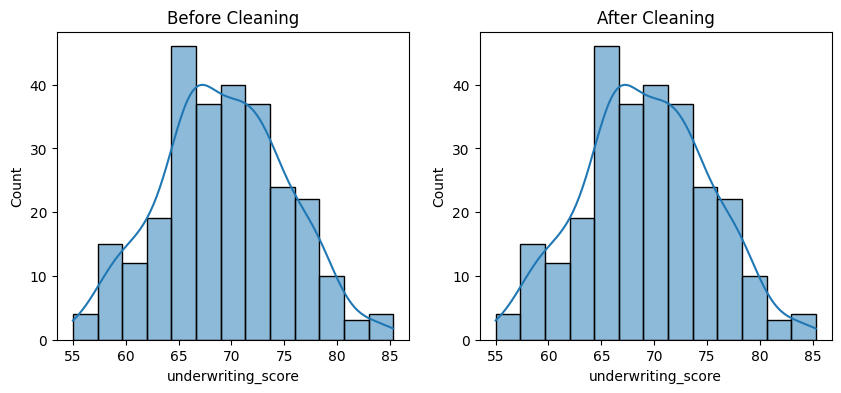

In [32]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_raw["underwriting_score"], kde=True)
plt.title("Before Cleaning")

plt.subplot(1,2,2)
sns.histplot(df["underwriting_score"], kde=True)
plt.title("After Cleaning")

plt.show()


In [33]:
cleaned_path = "/content/drive/MyDrive/CF/data/cleaned_data.xlsx"

df.to_excel(cleaned_path, index=False)

print("Saved at:", cleaned_path)


Saved at: /content/drive/MyDrive/CF/data/cleaned_data.xlsx


Median was used for numerical missing values to reduce the impact of outliers.

Mode was used for categorical missing values to preserve frequent categories.

IQR method was applied to detect and remove extreme outliers.
Feature engineering was performed to improve model interpretability.

In [34]:
print("Before cleaning:", df_raw.shape)
print("After cleaning:", df.shape)


Before cleaning: (273, 45)
After cleaning: (273, 45)


In [35]:
# Final validation
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())


Missing values: 0
Duplicates: 0


In [36]:
comparison = pd.DataFrame({
    "Before": df_raw.describe().loc["mean"],
    "After": df.describe().loc["mean"]
})

comparison.head()


,Before,After
builder_years_in_business,22.699634,22.699634
projects_completed,57.549451,57.549451
avg_delay_months,4.287912,4.287912
debt_to_equity_ratio,1.037399,1.037399
rera_violations,0.875458,0.875458


# analysis and visualization